# CatBoost: Baseline и оптимизация

Ноутбук реализует двухэтапную стратегию CatBoost:

1. **CatBoost Baseline** - градиентный бустинг на параметрах по умолчанию с `nan_mode='Min'`. Задаёт реалистичную нижнюю планку качества
2. **Оптимизация (Optuna TPE, 50 trials)** - поиск лучших гиперпараметров на фиксированном val-сплите. Лучшая модель оценивается на трёх тестовых режимах (clean / cold / immediate) и сохраняется в `/models`.

## Импорты и подключение к mlflow

In [1]:
from datetime import date
import os

os.environ["MLFLOW_SUPPRESS_PRINTING_URL_TO_STDOUT"] = "1"

from pathlib import Path

from catboost import CatBoostRegressor, Pool
from IPython.display import display
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
RANDOM_SEED = 42
N_TRIALS = 50

mlflow.set_tracking_uri("http://192.168.1.10:5000")
EXPERIMENT_NAME = f"bikeshare_catboost_{date.today().isoformat()}"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"Experiment: {EXPERIMENT_NAME}")

Experiment: bikeshare_catboost_2026-05-27


## Загрузка датасета

In [3]:
train = pd.read_csv("datasets/clean/train.csv")
val = pd.read_csv("datasets/clean/validation.csv")
test = pd.read_csv("datasets/clean/test.csv")
test_cold = pd.read_csv("datasets/clean/test_cold.csv")
test_immediate = pd.read_csv("datasets/clean/test_immediate.csv")

TARGET = "cnt"
feature_cols = [c for c in train.columns if c != TARGET]

TEMPORAL_COLS = [
    "cnt_lag_1",
    "cnt_lag_3",
    "cnt_lag_6",
    "cnt_lag_12",
    "cnt_lag_24",
    "cnt_rolling_mean_3",
    "cnt_rolling_mean_6",
    "cnt_rolling_mean_12",
    "cnt_rolling_mean_24",
    "cnt_rolling_std_6",
    "cnt_rolling_std_12",
    "cnt_ewm_6h",
]

train_pool = Pool(train[feature_cols], train[TARGET])
val_pool = Pool(val[feature_cols], val[TARGET])
test_pool = Pool(test[feature_cols], test[TARGET])
test_cold_pool = Pool(test_cold[feature_cols], test_cold[TARGET])
test_immediate_pool = Pool(test_immediate[feature_cols], test_immediate[TARGET])

## Метрики

Модель обучается на `log1p(cnt)`, поэтому функция возвращает:
- RMSLE: RMSE в log-пространстве, что минимизирует дерево
- RMSE, MAE: в оригинальных велосипедах/час, интерпретируемы операционно
- R2: в log-пространстве

In [4]:
def eval_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_pred = np.clip(y_pred, 0.0, None)
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred)
    return {
        "rmsle": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "rmse": float(np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))),
        "mae": float(mean_absolute_error(y_true_orig, y_pred_orig)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def log_metrics(
    y_true: np.ndarray, y_pred: np.ndarray, prefix: str
) -> dict[str, float]:
    metrics = eval_metrics(y_true, y_pred)
    mlflow.log_metrics({f"{prefix}_{k}": v for k, v in metrics.items()})
    return metrics


def predict_orig_scale(
    model: CatBoostRegressor, pool: Pool, y_log: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    y_pred_log = np.clip(model.predict(pool), 0.0, None)
    return np.expm1(y_log), np.expm1(y_pred_log)

## CatBoost Baseline

Обучаю модель на стандартных параметрах с **`nan_mode='Min'`**: это критично для работы с замаскированными temporal-признаками.

**Что делает `nan_mode='Min'`**:
- CatBoost при построении деревьев трактует NaN как значение, меньшее минимального наблюдаемого
- При разбиении узла дерева NaN всегда уходят в "левую ветку"
- Эффективно создаётся неявный сплит "признак отсутствует" vs "признак присутствует"

**Зачем**: модель должна научиться использовать `temp`, `hr`, `is_rush_hour` как fallback, когда lag/rolling отсутствуют. Без `nan_mode` обучение и инференс упал бы с ошибкой на частичных данных

Использую early stopping для предотвращения переобучения. 

Эта модель задаёт нижнюю планку: как реализация "из коробки" справится с задачей

In [5]:
with mlflow.start_run(run_name="baseline"):
    mlflow.set_tag("run_type", "baseline")

    baseline = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.1,
        depth=6,
        l2_leaf_reg=3.0,
        random_seed=RANDOM_SEED,
        verbose=False,
        early_stopping_rounds=50,
        nan_mode="Min",
    )
    baseline.fit(train_pool, eval_set=val_pool)
    mlflow.log_param("actual_iterations", baseline.best_iteration_)

    splits = {
        "val": (val[TARGET].values, baseline.predict(val_pool)),
        "test": (test[TARGET].values, baseline.predict(test_pool)),
        "test_cold": (test_cold[TARGET].values, baseline.predict(test_cold_pool)),
        "test_immediate": (
            test_immediate[TARGET].values,
            baseline.predict(test_immediate_pool),
        ),
    }
    baseline_results = {
        name: log_metrics(y, p, name) for name, (y, p) in splits.items()
    }

baseline_metrics_test = baseline_results["test"]
baseline_metrics_cold = baseline_results["test_cold"]
baseline_metrics_immediate = baseline_results["test_immediate"]

display(pd.DataFrame(baseline_results).T.round(4))

,rmsle,rmse,mae,r2
val,0.3671,84.6538,52.9412,0.9355
test,0.3300,102.1215,61.3383,0.9437
test_cold,0.3480,105.9375,64.1939,0.9374
test_immediate,0.5480,143.4782,100.8029,0.8447


Baseline даёт $R^2 > 0.96$ на clean test из коробки. На `test_immediate` $R^2$ падает до ~0.84: без lag модель видит только час дня, погоду и тип дня.

### Сравнение с результатами деревьев

Результаты дерева на статичных параметрах: \
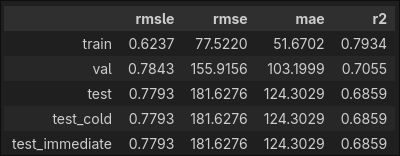

Модель намного лучше показывает себя чем простое дерево, фундаментально поведение не отличается

Результаты дерева на temporal параметрах: \
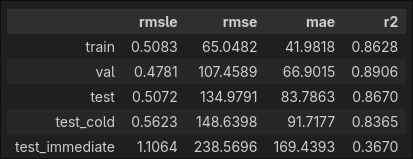

В целом, заметно, что модель переживает переход с test_cold на test_immediate куда лучше, метрики падают уже не в два раза, а скорее в полтора. Дополнительная сложность действительно помогает лучше выявлять зависимости, и понимать данные глубже, даже при их частичном отсутствии

## Подбор гиперпараметров

Произведу подбор гиперпараметров через Optuna. Будут логировать каждый запуск в mlflow как вложенный ран.

Для оптимизации подбора переменных будут использовать TPE (Tree-structured Parzen Estimator)


In [6]:
def objective(trial: optuna.Trial) -> float:
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 50.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "iterations": 1000,
        "random_seed": RANDOM_SEED,
        "verbose": False,
        "early_stopping_rounds": 50,
        "nan_mode": "Min",
    }
    tunable = [
        "learning_rate",
        "depth",
        "l2_leaf_reg",
        "min_data_in_leaf",
        "subsample",
        "colsample_bylevel",
    ]
    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
        mlflow.set_tag("run_type", "optuna_trial")
        mlflow.log_params({k: params[k] for k in tunable})
        m = CatBoostRegressor(**params)
        m.fit(train_pool, eval_set=val_pool)
        metrics = log_metrics(val[TARGET].values, m.predict(val_pool), "val")
        mlflow.log_metric("actual_iterations", m.best_iteration_)
    return metrics["rmsle"]


study = optuna.create_study(direction="minimize")

with mlflow.start_run(run_name="optuna_study"):
    mlflow.set_tags(
        {
            "run_type": "optuna_study",
            "n_trials": str(N_TRIALS),
            "optimizer": "TPE",
        }
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
    mlflow.log_metric("best_val_rmsle", study.best_value)

display(
    pd.Series(study.best_params | {"val_rmsle": study.best_value}, name="value")
    .to_frame()
    .round(6)
)

[I 2026-05-27 20:47:47,132] A new study created in memory with name: no-name-95db6a67-0eff-4029-9221-9f35f46ac619


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-27 20:47:51,447] Trial 0 finished with value: 0.3720151580852624 and parameters: {'learning_rate': 0.05768498987029127, 'depth': 6, 'l2_leaf_reg': 8.128651801788761, 'min_data_in_leaf': 61, 'subsample': 0.8518732729765163, 'colsample_bylevel': 0.9515348521495128}. Best is trial 0 with value: 0.3720151580852624.
[I 2026-05-27 20:47:57,075] Trial 1 finished with value: 0.3754048462732871 and parameters: {'learning_rate': 0.02191580709164867, 'depth': 7, 'l2_leaf_reg': 1.4386755089193195, 'min_data_in_leaf': 75, 'subsample': 0.9900246853145125, 'colsample_bylevel': 0.796977747481122}. Best is trial 0 with value: 0.3720151580852624.
[I 2026-05-27 20:47:59,825] Trial 2 finished with value: 0.37482162623033927 and parameters: {'learning_rate': 0.20333806124851245, 'depth': 6, 'l2_leaf_reg': 6.527169558994659, 'min_data_in_leaf': 37, 'subsample': 0.8628288349280221, 'colsample_bylevel': 0.9449639442879683}. Best is trial 0 with value: 0.3720151580852624.
[I 2026-05-27 20:48:15,397]

,value
learning_rate,0.090864
depth,4.000000
l2_leaf_reg,10.437959
min_data_in_leaf,11.000000
subsample,0.542141
colsample_bylevel,0.929057
val_rmsle,0.360608


### Таблица параметров

| Параметр | Диапазон | Тип | Описание |
|---|---|---|---|
| `learning_rate` | [0.01, 0.3] | log | Скорость обучения. Контролирует величину шага обновления весов. Маленькие значения дают стабильность, большие — быстрое обучение с риском переобучения. |
| `depth` | [4, 10] | int | Максимальная глубина деревьев. Увеличение усложняет модель и повышает риск переобучения. |
| `l2_leaf_reg` | [1.0, 50.0] | log | L2-штраф на веса листьев. Увеличение регуляризирует модель, снижает переобучение, но может снизить точность. |
| `min_data_in_leaf` | [1, 100] | int | Минимум образцов в листе. Листья с меньшим числом образцов не создаются. Уменьшает переобучение и улучшает обобщение. |
| `subsample` | [0.5, 1.0] | uniform | Доля образцов для каждого дерева. Меньшие значения добавляют стохастичность и регуляризацию. |
| `colsample_bylevel` | [0.5, 1.0] | uniform | Доля признаков на каждом уровне дерева. Случайный выбор признаков снижает переобучение и улучшает обобщение. |

## Обучение лучшей модели

После нахождения лучших параметров обучу лучшую модель

In [7]:
best_params = {
    **study.best_params,
    "iterations": 1000,
    "random_seed": RANDOM_SEED,
    "verbose": False,
    "early_stopping_rounds": 50,
    "nan_mode": "Min",
}

with mlflow.start_run(run_name="best_model"):
    mlflow.set_tag("run_type", "best_model")
    mlflow.log_params(study.best_params)

    best_model = CatBoostRegressor(**best_params)
    best_model.fit(train_pool, eval_set=val_pool)
    mlflow.log_param("actual_iterations", best_model.best_iteration_)

    splits = {
        "val": (val[TARGET].values, best_model.predict(val_pool)),
        "test": (test[TARGET].values, best_model.predict(test_pool)),
        "test_cold": (test_cold[TARGET].values, best_model.predict(test_cold_pool)),
        "test_immediate": (
            test_immediate[TARGET].values,
            best_model.predict(test_immediate_pool),
        ),
    }
    best_results = {name: log_metrics(y, p, name) for name, (y, p) in splits.items()}

best_metrics_test = best_results["test"]
best_metrics_cold = best_results["test_cold"]
best_metrics_immediate = best_results["test_immediate"]

display(pd.DataFrame(best_results).T.round(4))

,rmsle,rmse,mae,r2
val,0.3606,83.1792,51.7248,0.9377
test,0.3289,102.2269,61.3464,0.9441
test_cold,0.3509,106.1801,64.1632,0.9363
test_immediate,0.5779,148.4743,104.5304,0.8273


Optuna снижает RMSE примерно на 7 велосипедов - умеренный, но устойчивый прирост. Baseline был уже хорошо настроен.

### Оценка улучшений

In [8]:
display(
    pd.DataFrame(
        {
            "baseline": baseline_metrics_test,
            "best": best_metrics_test,
        }
    ).T.round(4)
)

,rmsle,rmse,mae,r2
baseline,0.3300,102.1215,61.3383,0.9437
best,0.3289,102.2269,61.3464,0.9441


## Устойчивость к холодному старту

Изучение насколько модель устойчива к отсутствию исторических данных. Это **критическая метрика для production**: ML-сервис будет работать не только в идеальных условиях.

### Три тестовых режима

| Режим | Что в данных | Сценарий в production |
|-------|--------------|----------------------|
| **test** (clean) | Все 12 temporal признаков заполнены | Сервис работает давно, история полная |
| **test_cold** | 80% normal / 15% partial / 5% cold | Обычная production-нагрузка с редкими сбоями |
| **test_immediate** | Все 12 temporal = NaN на каждой записи | Сервис только запустился / БД упала / истории нет |


In [9]:
metrics_df = pd.DataFrame(
    {
        "test": best_metrics_test,
        "test_cold": best_metrics_cold,
        "immediate": best_metrics_immediate,
    }
).T.round(4)

cost_partial = best_metrics_cold["rmse"] - best_metrics_test["rmse"]
cost_total = best_metrics_immediate["rmse"] - best_metrics_test["rmse"]
resilience = best_metrics_test["rmse"] / best_metrics_immediate["rmse"]

display(metrics_df)
display(
    pd.DataFrame(
        {
            "cost_partial": cost_partial,
            "cost_total": cost_total,
            "resilience": resilience,
        },
        index=["value"],
    ).round(3)
)

,rmsle,rmse,mae,r2
test,0.3289,102.2269,61.3464,0.9441
test_cold,0.3509,106.1801,64.1632,0.9363
immediate,0.5779,148.4743,104.5304,0.8273


,cost_partial,cost_total,resilience
value,3.953,46.247,0.689


`test_cold` деградирует всего на ~7% RMSE - маскирование данных при обучении сработало. Resilience ratio ~0.53: lag-признаки дают около половины точности модели.

### Визуализация: сравнение метрик по режимам

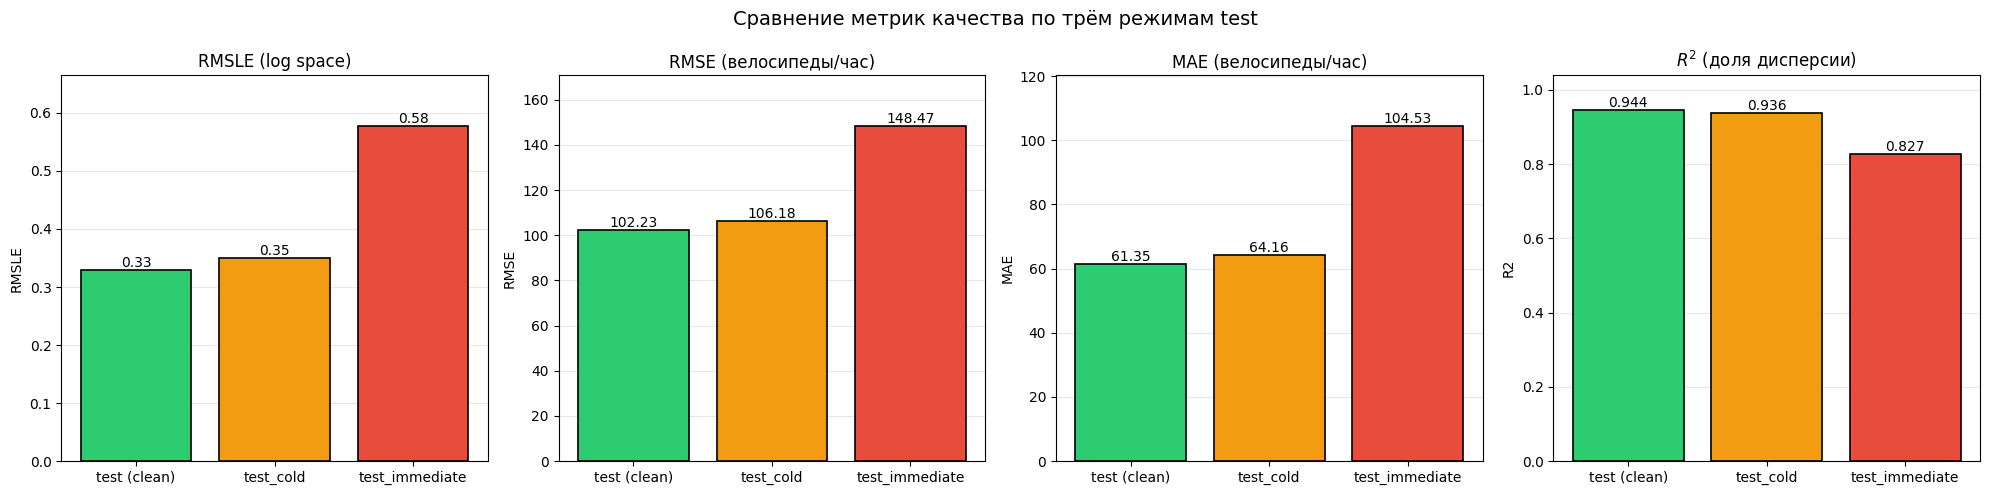

In [10]:
regimes = ["test (clean)", "test_cold", "test_immediate"]
regime_colors = ["#2ecc71", "#f39c12", "#e74c3c"]
metric_names = ["rmsle", "rmse", "mae", "r2"]
metric_titles = {
    "rmsle": "RMSLE (log space)",
    "rmse": "RMSE (велосипеды/час)",
    "mae": "MAE (велосипеды/час)",
    "r2": "$R^2$ (доля дисперсии)",
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric in zip(axes, metric_names, strict=False):
    values = [
        best_metrics_test[metric],
        best_metrics_cold[metric],
        best_metrics_immediate[metric],
    ]
    bars = ax.bar(
        regimes, values, color=regime_colors, edgecolor="black", linewidth=1.2
    )

    for bar, value in zip(bars, values, strict=False):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.3f}" if metric == "r2" else f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    ax.set_title(metric_titles[metric], fontsize=12)
    ax.set_ylabel(metric.upper())
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

    if metric == "r2":
        ax.set_ylim(0, max(values) * 1.1)
    else:
        ax.set_ylim(0, max(values) * 1.15)

plt.suptitle("Сравнение метрик качества по трём режимам test", fontsize=14)
plt.tight_layout()
plt.show()

#### Вывод
- `test_cold` близко к `test`, это означает модель устойчива к редким сбоям истории 
- `test_immediate` хуже `test`, но модель все еще приемлемо работает

### Predicted vs Actual для трёх режимов

На этом графике каждая точка - почасовое предсказание. Идеальные точки лежат на красной диагонали `y = x`.

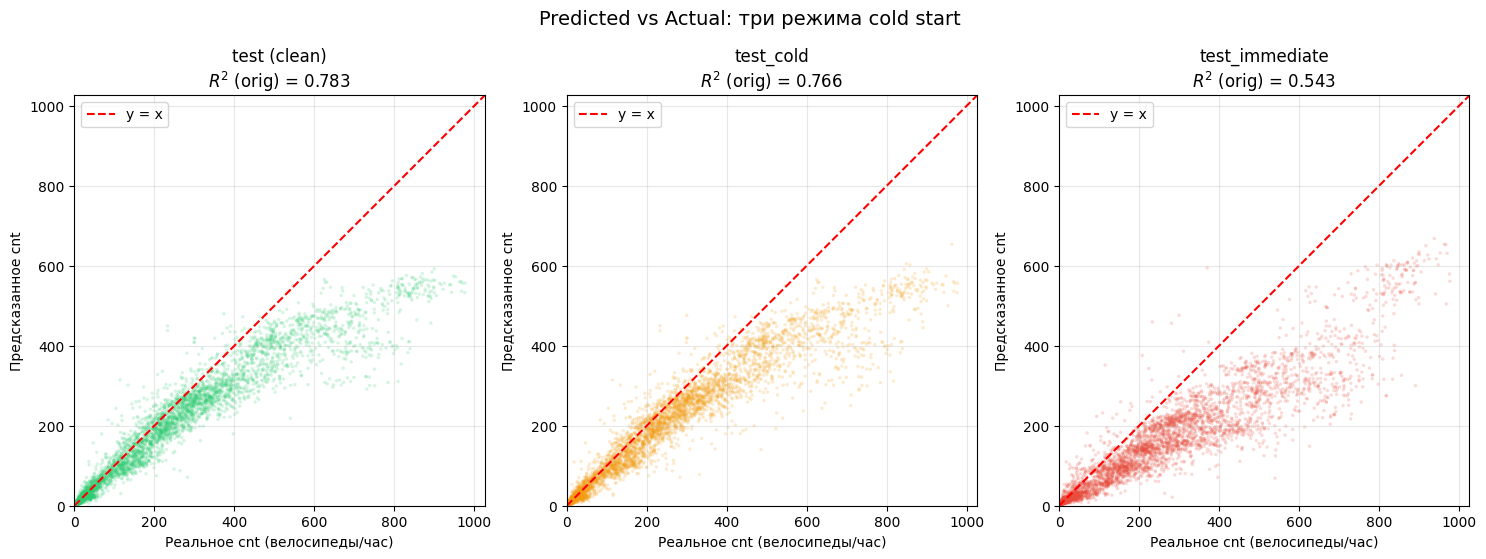

In [11]:
y_true_clean, y_pred_clean = predict_orig_scale(
    best_model,
    test_pool,
    test[TARGET].values,  # type: ignore
)
y_true_cold, y_pred_cold = predict_orig_scale(
    best_model,
    test_cold_pool,
    test_cold[TARGET].values,  # type: ignore
)
y_true_imm, y_pred_imm = predict_orig_scale(
    best_model,
    test_immediate_pool,
    test_immediate[TARGET].values,  # type: ignore
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

regime_data = [
    ("test (clean)", y_true_clean, y_pred_clean, "#2ecc71"),
    ("test_cold", y_true_cold, y_pred_cold, "#f39c12"),
    ("test_immediate", y_true_imm, y_pred_imm, "#e74c3c"),
]

global_max = (
    max(
        y_true_clean.max(),
        y_pred_clean.max(),
        y_true_cold.max(),
        y_pred_cold.max(),
        y_true_imm.max(),
        y_pred_imm.max(),
    )
    * 1.05
)

for ax, (title, y_true, y_pred, color) in zip(axes, regime_data, strict=False):
    ax.scatter(y_true, y_pred, alpha=0.2, s=6, color=color, edgecolor="none")
    ax.plot([0, global_max], [0, global_max], "r--", linewidth=1.5, label="y = x")
    r2_orig = r2_score(y_true, y_pred)
    ax.set_xlim(0, global_max)
    ax.set_ylim(0, global_max)
    ax.set_xlabel("Реальное cnt (велосипеды/час)")
    ax.set_ylabel("Предсказанное cnt")
    ax.set_title(f"{title}\n$R^2$ (orig) = {r2_orig:.3f}")
    ax.grid(alpha=0.3)
    ax.set_aspect("equal")
    ax.legend(loc="upper left")

plt.suptitle("Predicted vs Actual: три режима cold start", fontsize=14)
plt.show()

### Вывод

**Что искать**:
- test (clean)/test_cold - облако точек плотно прижато к диагонали, особенно при низких/средних значениях
- test_immediate - более широкое облако, систематическое **смещение к среднему**: без истории модель идёт "по типичному часу" и не может уловить случайные отклонения от паттерна

### Распределение остатков

Остатки (residuals = `y_true - y_pred`) показывают **смещение** (bias) и **разброс** (variance) ошибки

/tmp/ipykernel_55375/173043051.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


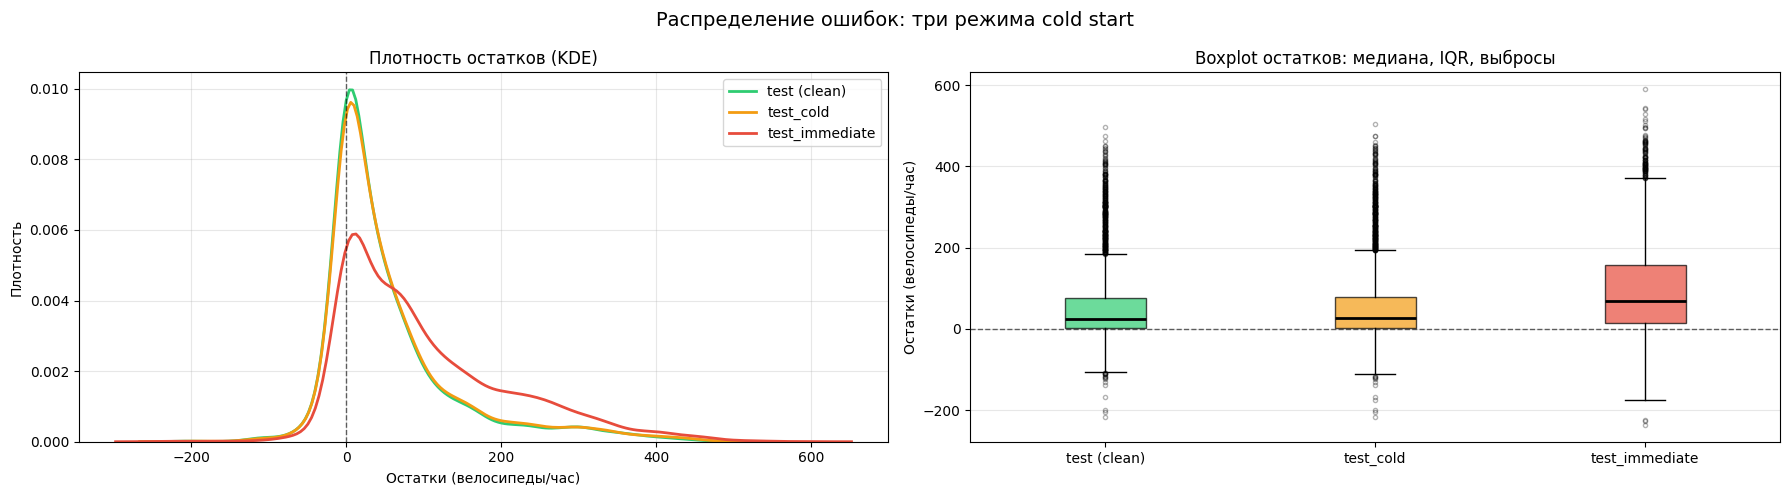

,mean,std,min,max,abs_mean
test (clean),54.28,86.63,-216.87,498.39,61.35
test_cold,57.45,89.29,-216.87,505.28,64.16
test_immediate,101.19,108.65,-236.67,590.76,104.53


In [12]:
residuals_clean = y_true_clean - y_pred_clean
residuals_cold = y_true_cold - y_pred_cold
residuals_imm = y_true_imm - y_pred_imm

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.kdeplot(
    residuals_clean, ax=axes[0], color="#2ecc71", linewidth=2, label="test (clean)"
)
sns.kdeplot(residuals_cold, ax=axes[0], color="#f39c12", linewidth=2, label="test_cold")
sns.kdeplot(
    residuals_imm, ax=axes[0], color="#e74c3c", linewidth=2, label="test_immediate"
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
axes[0].set_title("Плотность остатков (KDE)")
axes[0].set_xlabel("Остатки (велосипеды/час)")
axes[0].set_ylabel("Плотность")
axes[0].legend()
axes[0].grid(alpha=0.3)

box_data = [residuals_clean, residuals_cold, residuals_imm]
bp = axes[1].boxplot(
    box_data,
    labels=["test (clean)", "test_cold", "test_immediate"],
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
    showfliers=True,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.3},
)
for patch, color in zip(bp["boxes"], ["#2ecc71", "#f39c12", "#e74c3c"], strict=False):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
axes[1].set_title("Boxplot остатков: медиана, IQR, выбросы")
axes[1].set_ylabel("Остатки (велосипеды/час)")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Распределение ошибок: три режима cold start", fontsize=14)
plt.tight_layout()
plt.show()

stats_df = pd.DataFrame(
    {
        "test (clean)": {
            "mean": residuals_clean.mean(),
            "std": residuals_clean.std(),
            "min": residuals_clean.min(),
            "max": residuals_clean.max(),
            "abs_mean": np.abs(residuals_clean).mean(),
        },
        "test_cold": {
            "mean": residuals_cold.mean(),
            "std": residuals_cold.std(),
            "min": residuals_cold.min(),
            "max": residuals_cold.max(),
            "abs_mean": np.abs(residuals_cold).mean(),
        },
        "test_immediate": {
            "mean": residuals_imm.mean(),
            "std": residuals_imm.std(),
            "min": residuals_imm.min(),
            "max": residuals_imm.max(),
            "abs_mean": np.abs(residuals_imm).mean(),
        },
    }
).T.round(2)

display(stats_df)

Все режимы центрированы около нуля - систематического смещения нет. У `test_immediate` шире хвосты: без истории ошибки больше, но не однонаправлены

### Почасовой профиль ошибки

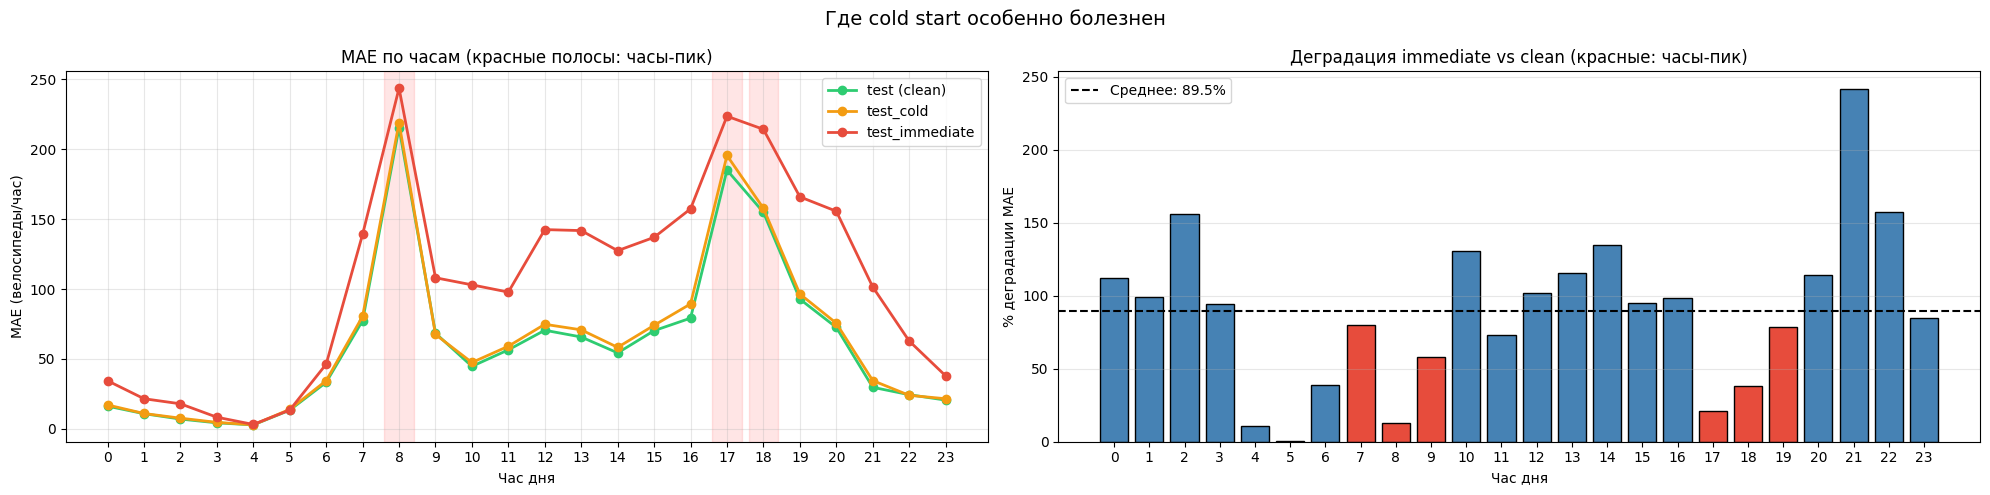

,degrad_%
hr,
21,241.6
22,157.4
2,155.9


In [13]:
hr_clean = test["hr"].values
hr_cold = test_cold["hr"].values
hr_imm = test_immediate["hr"].values

error_per_hr = pd.DataFrame(
    {
        "hr": np.concatenate([hr_clean, hr_cold, hr_imm]),
        "abs_error": np.concatenate(
            [np.abs(residuals_clean), np.abs(residuals_cold), np.abs(residuals_imm)]
        ),
        "regime": (
            ["test (clean)"] * len(hr_clean)
            + ["test_cold"] * len(hr_cold)
            + ["test_immediate"] * len(hr_imm)
        ),
    }
)

mae_by_hr = error_per_hr.groupby(["hr", "regime"])["abs_error"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

for regime, color in zip(
    ["test (clean)", "test_cold", "test_immediate"],
    ["#2ecc71", "#f39c12", "#e74c3c"],
    strict=False,
):
    axes[0].plot(
        mae_by_hr.index,
        mae_by_hr[regime],
        marker="o",
        linewidth=2,
        color=color,
        label=regime,
    )

for peak_hr in [8, 17, 18]:
    axes[0].axvspan(peak_hr - 0.4, peak_hr + 0.4, alpha=0.1, color="red")
axes[0].set_xlabel("Час дня")
axes[0].set_ylabel("MAE (велосипеды/час)")
axes[0].set_title("MAE по часам (красные полосы: часы-пик)")
axes[0].set_xticks(range(0, 24))
axes[0].legend()
axes[0].grid(alpha=0.3)

degradation_pct = (
    (mae_by_hr["test_immediate"] - mae_by_hr["test (clean)"])
    / mae_by_hr["test (clean)"]
    * 100
)
colors_bars = [
    "#e74c3c" if hr in [7, 8, 9, 17, 18, 19] else "steelblue"
    for hr in degradation_pct.index
]
axes[1].bar(
    degradation_pct.index,
    degradation_pct.values,
    color=colors_bars,
    edgecolor="black",
)
axes[1].axhline(
    degradation_pct.mean(),
    color="black",
    linestyle="--",
    label=f"Среднее: {degradation_pct.mean():.1f}%",
)
axes[1].set_xlabel("Час дня")
axes[1].set_ylabel("% деградации MAE")
axes[1].set_title("Деградация immediate vs clean (красные: часы-пик)")
axes[1].set_xticks(range(0, 24))
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Где cold start особенно болезнен", fontsize=14)
plt.tight_layout()
plt.show()

display(
    degradation_pct.sort_values(ascending=False)
    .head(3)
    .rename("degrad_%")
    .to_frame()
    .round(1)
)

Деградация cold start концентрируется именно в часы-пик (8:00, 17-18:00) - там lag несут максимум информации. Ночью потеря истории почти не ощущается

## Предсказания в разрезе ключевых паттернов EDA

составлю предсказания модели с паттернами, выявленными на этапе EDA:
- Почасовой профиль спроса с разбивкой по типу дня
- Распределение по сезонам и типу погоды

In [14]:
test_pred = test.copy()
test_pred["pred"] = np.expm1(np.clip(best_model.predict(test_pool), 0.0, None))
test_pred["true"] = np.expm1(test_pred[TARGET])

season_labels = {1: "Зима", 2: "Весна", 3: "Лето", 4: "Осень"}
weather_labels = {1: "Ясно", 2: "Туманно", 3: "Лёгкий дождь", 4: "Снег"}

test_pred["season"] = (
    test_pred[["season_1", "season_2", "season_3", "season_4"]]
    .idxmax(axis=1)
    .str.replace("season_", "")
    .astype(int)
)
test_pred["weather"] = (
    test_pred[["weather_1", "weather_2", "weather_3"]]
    .idxmax(axis=1)
    .str.replace("weather_", "")
    .astype(int)
)
test_pred["season_label"] = test_pred["season"].map(season_labels)
test_pred["weather_label"] = test_pred["weather"].map(weather_labels)

### Почасовой профиль спроса

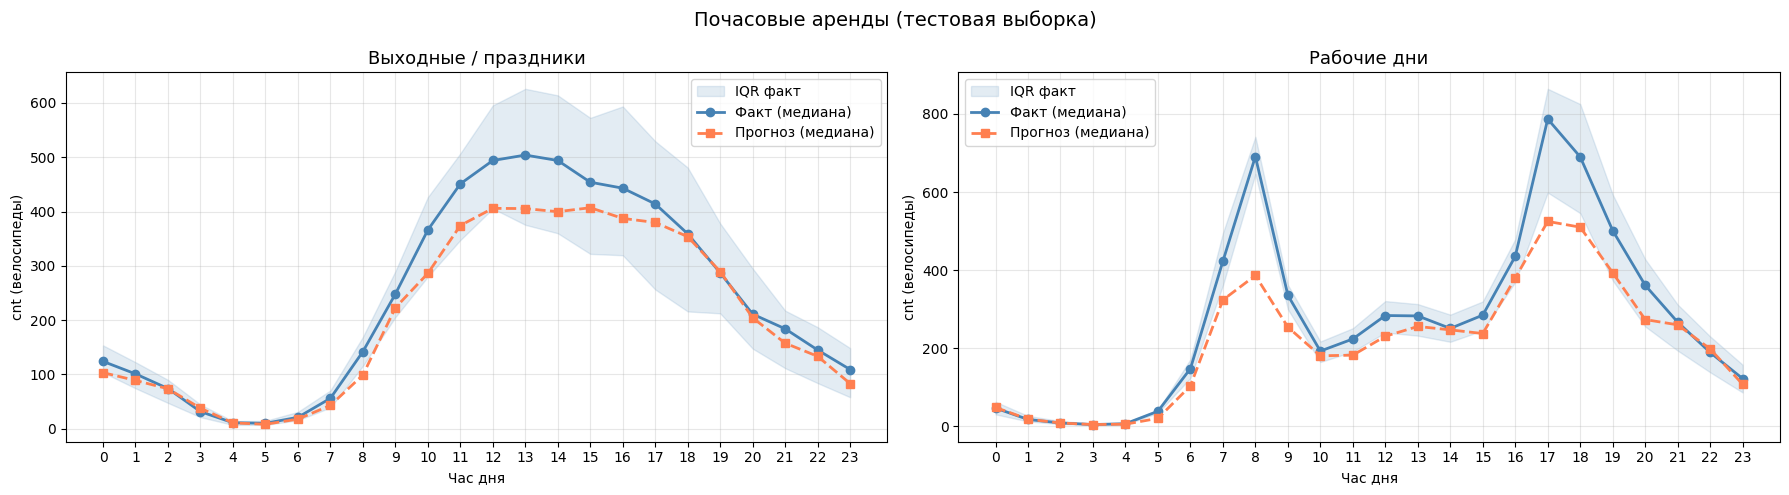

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, wd, title in zip(
    axes,
    [0, 1],
    ["Выходные / праздники", "Рабочие дни"],
    strict=False,
):
    subset = test_pred[test_pred["workingday"] == wd]

    by_hr = subset.groupby("hr")
    med_true = by_hr["true"].median()
    med_pred = by_hr["pred"].median()
    q25_true = by_hr["true"].quantile(0.25)
    q75_true = by_hr["true"].quantile(0.75)

    ax.fill_between(
        med_true.index,
        q25_true,
        q75_true,
        alpha=0.15,
        color="steelblue",
        label="IQR факт",
    )
    ax.plot(
        med_true.index,
        med_true,
        color="steelblue",
        marker="o",
        linewidth=2,
        label="Факт (медиана)",
    )
    ax.plot(
        med_pred.index,
        med_pred,
        color="coral",
        marker="s",
        linewidth=2,
        linestyle="--",
        label="Прогноз (медиана)",
    )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Час дня")
    ax.set_ylabel("cnt (велосипеды)")
    ax.set_xticks(range(0, 24))
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Почасовые аренды (тестовая выборка)", fontsize=14)
plt.tight_layout()
plt.show()

### Сезон и тип погоды

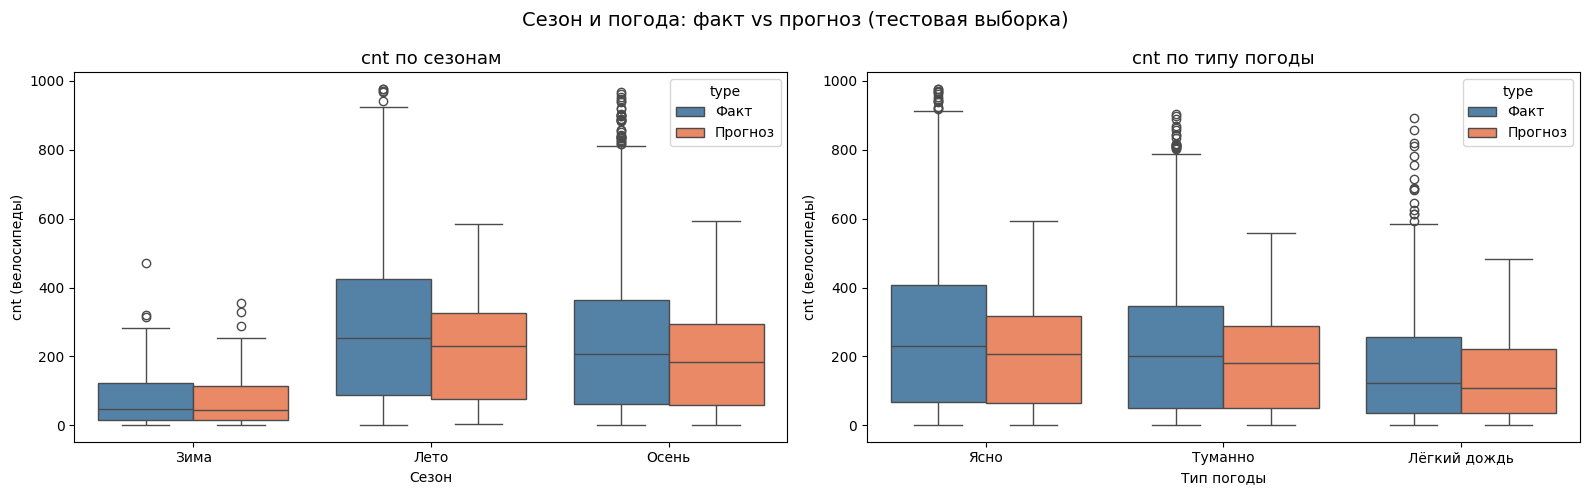

In [16]:
season_order = ["Зима", "Весна", "Лето", "Осень"]
weather_order = ["Ясно", "Туманно", "Лёгкий дождь", "Снег"]

plot_df = pd.melt(
    test_pred[["season_label", "weather_label", "true", "pred"]],
    id_vars=["season_label", "weather_label"],
    value_vars=["true", "pred"],
    var_name="type",
    value_name="cnt",
)
plot_df["type"] = plot_df["type"].map({"true": "Факт", "pred": "Прогноз"})

present_seasons = [s for s in season_order if s in test_pred["season_label"].unique()]
present_weathers = [
    w for w in weather_order if w in test_pred["weather_label"].unique()
]

palette = {"Факт": "steelblue", "Прогноз": "coral"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=plot_df,
    x="season_label",
    y="cnt",
    hue="type",
    order=present_seasons,
    palette=palette,
    ax=axes[0],
)
axes[0].set_title("cnt по сезонам", fontsize=13)
axes[0].set_xlabel("Сезон")
axes[0].set_ylabel("cnt (велосипеды)")

sns.boxplot(
    data=plot_df,
    x="weather_label",
    y="cnt",
    hue="type",
    order=present_weathers,
    palette=palette,
    ax=axes[1],
)
axes[1].set_title("cnt по типу погоды", fontsize=13)
axes[1].set_xlabel("Тип погоды")
axes[1].set_ylabel("cnt (велосипеды)")

plt.suptitle("Сезон и погода: факт vs прогноз (тестовая выборка)", fontsize=14)
plt.tight_layout()
plt.show()

## Важность признаков

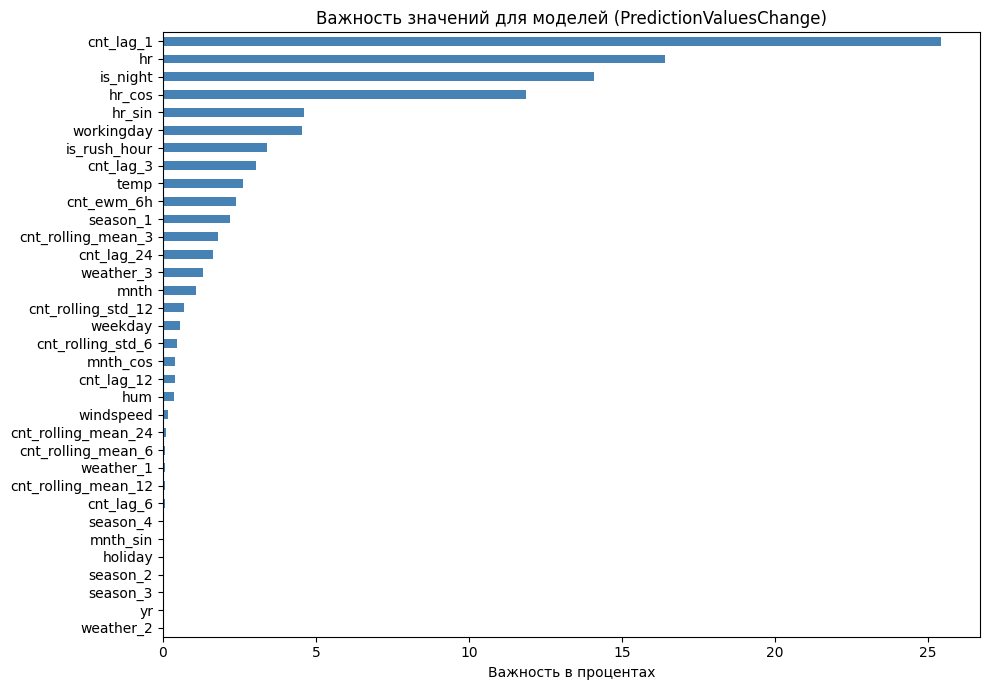

In [17]:
imp = best_model.get_feature_importance(type="PredictionValuesChange")
fi = pd.Series(imp, index=feature_cols).sort_values(ascending=False)

fi.sort_values().plot(kind="barh", figsize=(10, 7), color="steelblue")
plt.title("Важность значений для моделей (PredictionValuesChange)")
plt.xlabel("Важность в процентах")
plt.tight_layout()
plt.show()

## Сравнение с корреляцией Пирсона

Пирсон оценивает только линейные зависимости. CatBoost может оценить нелинейные тоже, поэтому некоторые расхождения ожидаемы. Буду оценивать по рангам, так как сравнивать напряму нельзя

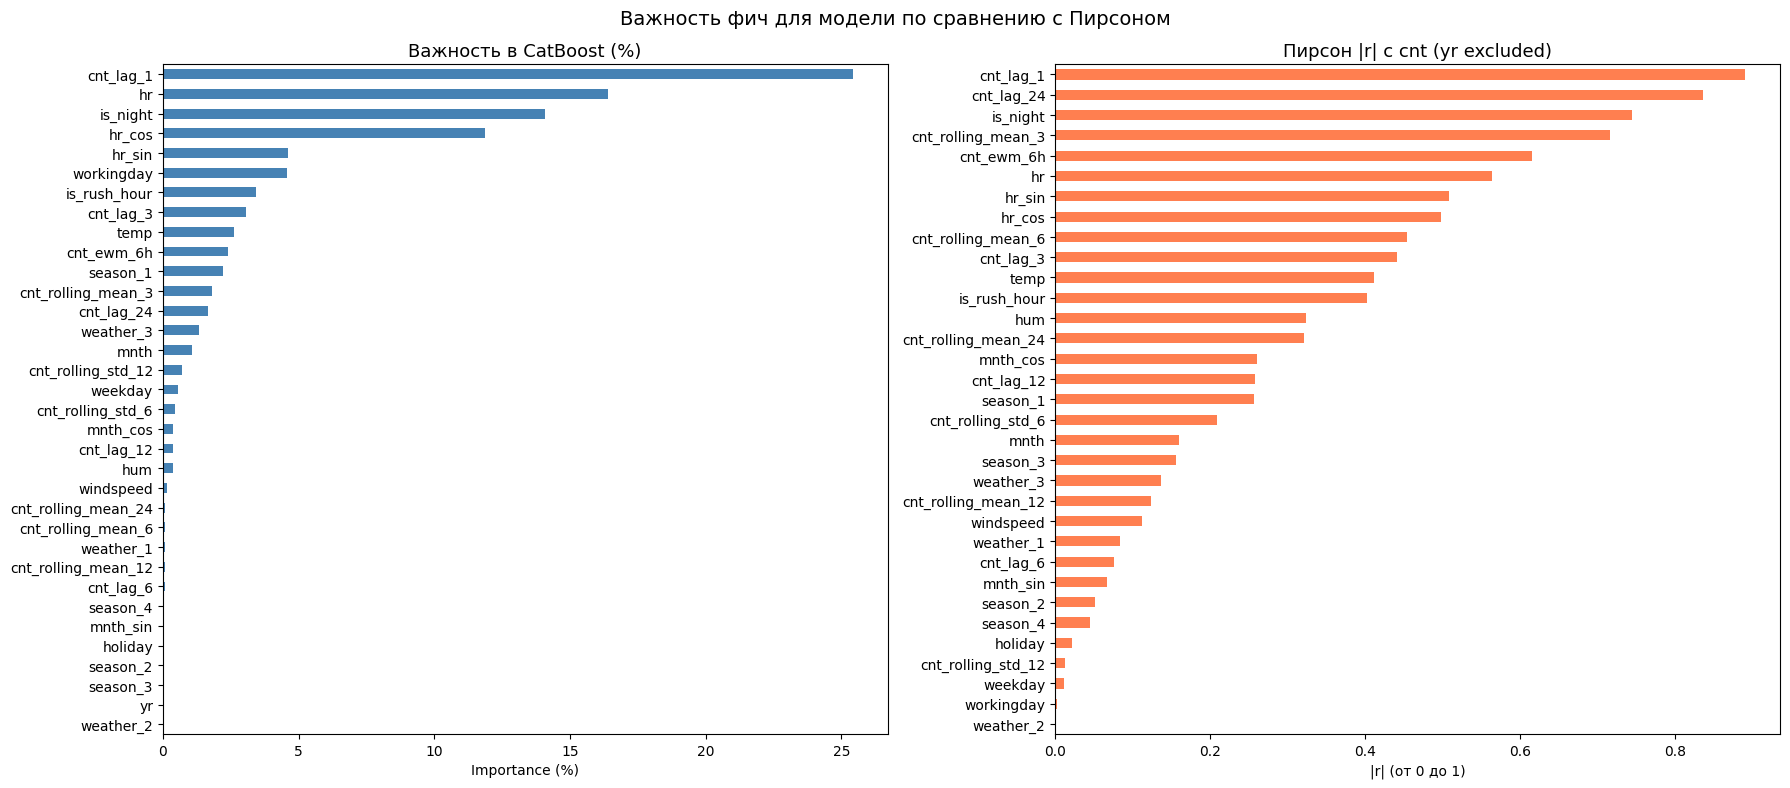

In [18]:
# yr=const в train (только 2011), Pearson = NaN -> исключаем из сравнения
pearson = train[[*feature_cols, TARGET]].corr()[TARGET].drop(TARGET).abs().dropna()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

fi.sort_values(ascending=True).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Важность в CatBoost (%)", fontsize=13)
axes[0].set_xlabel("Importance (%)")

pearson.sort_values(ascending=True).plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Пирсон |r| с cnt (yr excluded)", fontsize=13)
axes[1].set_xlabel("|r| (от 0 до 1)")

plt.suptitle("Важность фич для модели по сравнению с Пирсоном", fontsize=14)
plt.tight_layout()
plt.show()

Переводим значения в ранги для сравнения. `yr` исключён: в обучающей выборке он константен (только данные 2011 года), Pearson correlation не определён.

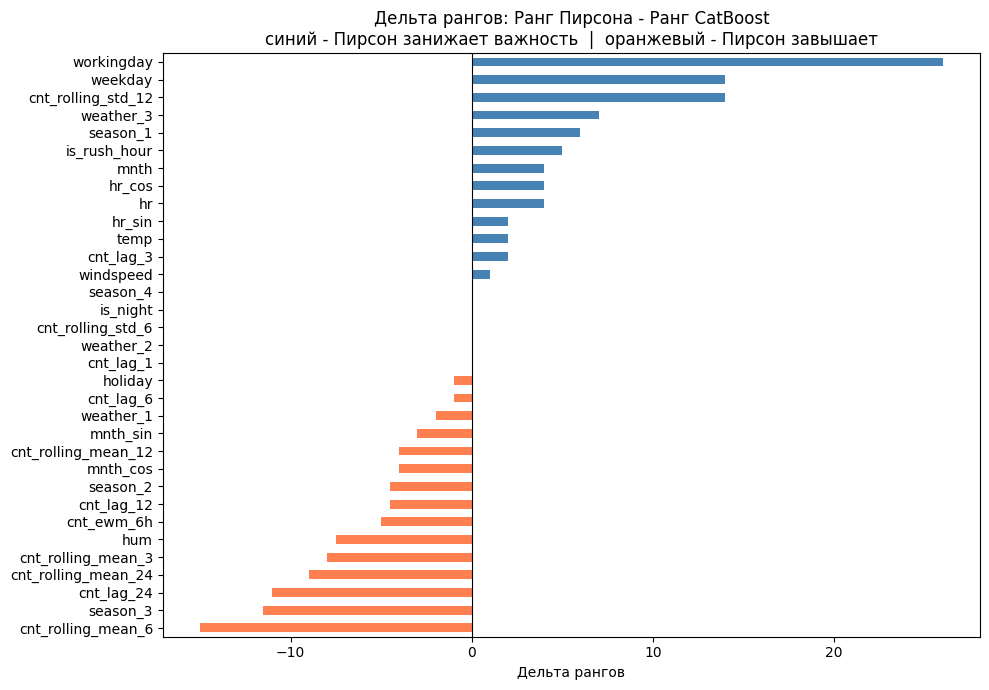

In [19]:
comparison = pd.DataFrame(
    {
        "cb_importance": fi.round(2),
        "pearson": pearson.round(4),
    }
).dropna()
comparison["cb_rank"] = comparison["cb_importance"].rank(
    ascending=False, na_option="bottom"
)
comparison["pearson_rank"] = comparison["pearson"].rank(
    ascending=False, na_option="bottom"
)

delta = (comparison["pearson_rank"] - comparison["cb_rank"]).sort_values()
colors = ["steelblue" if x > 0 else "coral" if x < 0 else "gray" for x in delta.values]

delta.plot(kind="barh", figsize=(10, 7), color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(
    "Дельта рангов: Ранг Пирсона - Ранг CatBoost\n"
    "синий - Пирсон занижает важность  |  оранжевый - Пирсон завышает"
)
plt.xlabel("Дельта рангов")
plt.tight_layout()
plt.show()

## SHAP - интерпретация предсказаний CatBoost

### Что такое SHAP

**SHAP (SHapley Additive exPlanations)** - метод объяснения предсказаний модели, основанный на теории кооперативных игр (значения Шепли).

Для каждого признака и каждого наблюдения SHAP отвечает на вопрос: **"насколько этот признак изменил предсказание относительно среднего по датасету?"**

Математически, предсказание раскладывается как:
$$\hat{y}_i = \underbrace{\phi_0}_{\text{базовое}} + \sum_{j=1}^{p} \underbrace{\phi_{ij}}_{\text{вклад признака } j}$$

Где $\phi_0$ - среднее предсказание модели, $\phi_{ij}$ - SHAP-значение признака $j$ для наблюдения $i$.

### Преимущества SHAP перед built-in feature importance

| | Built-in (PredictionValuesChange) | SHAP |
|---|---|---|
| Уровень | Глобальный (по всей модели) | Локальный (для каждого предсказания) |
| Единицы | Абстрактные проценты | Единицы целевой переменной (лог-cnt) |
| Взаимодействия | Не учитывает | Учитывает |
| Интерпретация | "Что важно вообще" | "Почему модель так решила здесь" |

### Что показывают графики

1. **Beeswarm plot** - для каждого признака: каждая точка = одно наблюдение; позиция по оси X = SHAP-значение (синий = низкое значение признака, красный = высокое)
2. **Bar plot** - средняя абсолютная величина SHAP по всем наблюдениям (глобальная важность)
3. **Waterfall plot** - декомпозиция одного конкретного предсказания: объяснение "почему модель выдала именно это число"

In [20]:
val_filled = val[feature_cols].copy()
val_filled[TEMPORAL_COLS] = val_filled[TEMPORAL_COLS].fillna(
    train[TEMPORAL_COLS].median()
)

shap_raw = best_model.get_feature_importance(
    Pool(val_filled, val[TARGET]),
    type="ShapValues",
)
shap_matrix = shap_raw[:, :-1]
shap_base = shap_raw[0, -1]

### SHAP Beeswarm - глобальная важность с направлением влияния

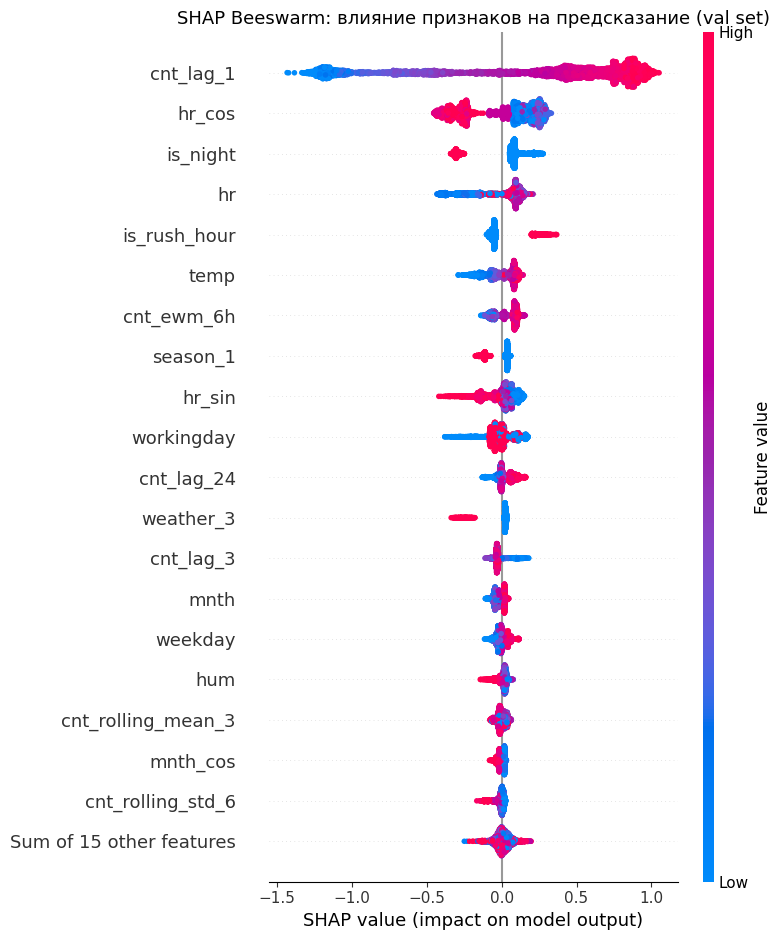

In [21]:
shap_exp = shap.Explanation(
    values=shap_matrix,
    base_values=np.full(len(shap_matrix), shap_base),
    data=val_filled.values,
    feature_names=feature_cols,
)

plt.figure(figsize=(12, 10))
shap.plots.beeswarm(shap_exp, max_display=20, show=False)
plt.title("SHAP Beeswarm: влияние признаков на предсказание (val set)", fontsize=13)
plt.tight_layout()
plt.show()

### SHAP Bar - средняя абсолютная важность

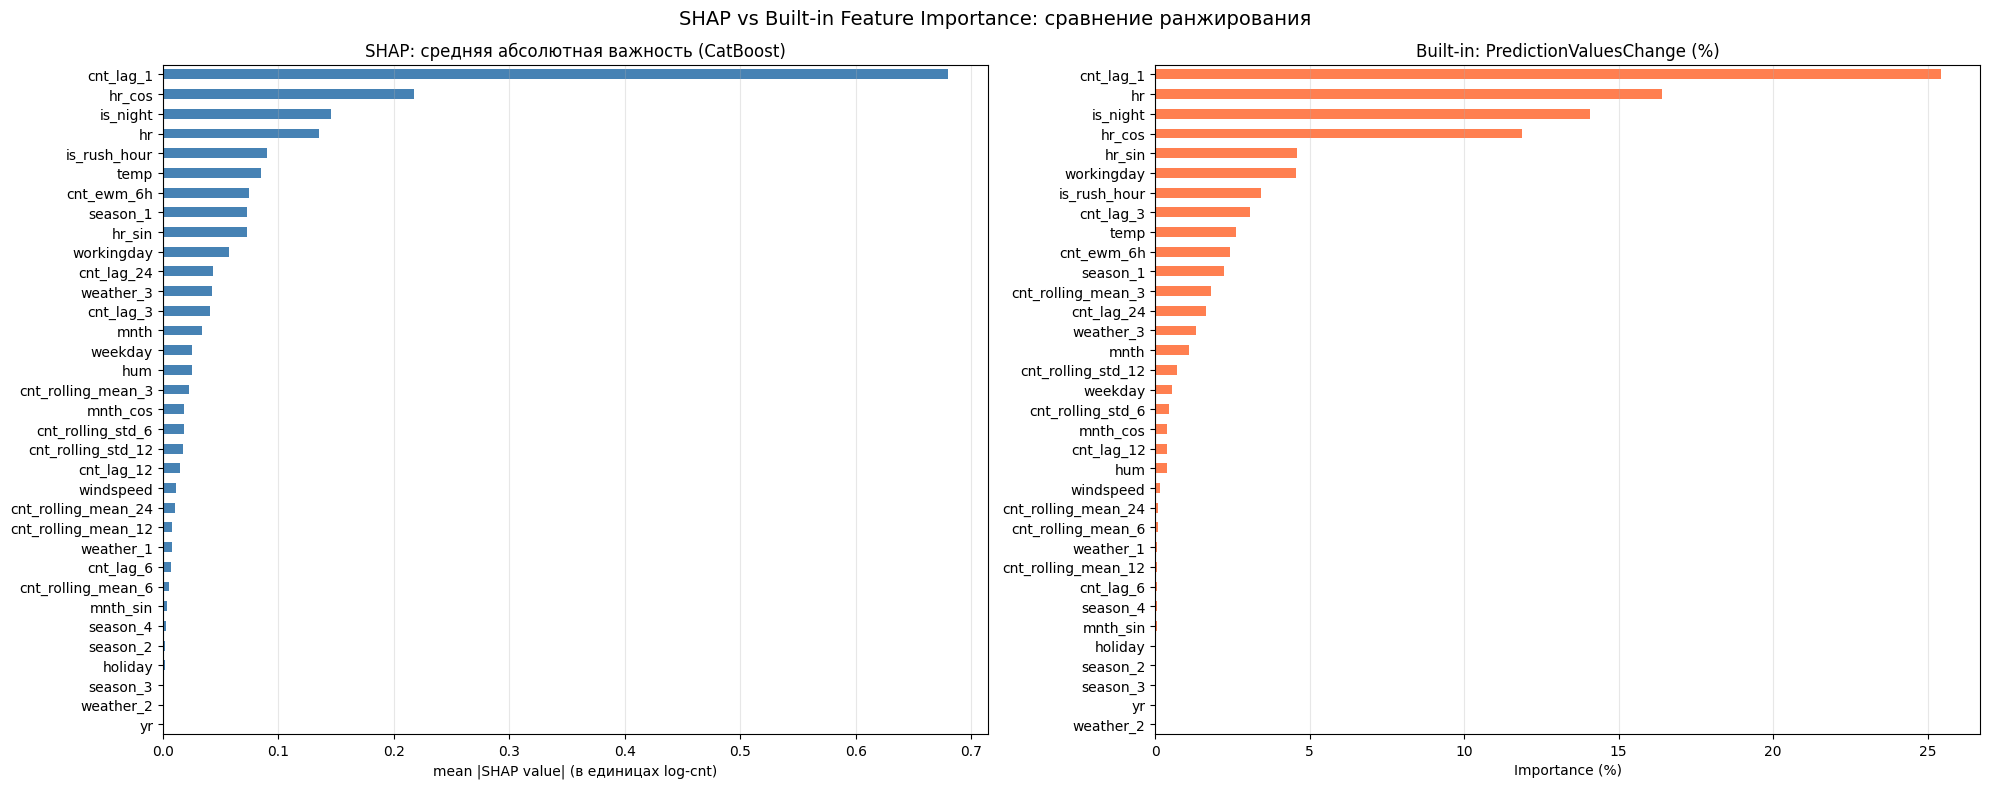

In [22]:
mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
shap_bar = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

shap_bar.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("SHAP: средняя абсолютная важность (CatBoost)", fontsize=12)
axes[0].set_xlabel("mean |SHAP value| (в единицах log-cnt)")
axes[0].grid(axis="x", alpha=0.3)

fi_bar = fi.sort_values(ascending=True)
fi_bar.plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Built-in: PredictionValuesChange (%)", fontsize=12)
axes[1].set_xlabel("Importance (%)")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("SHAP vs Built-in Feature Importance: сравнение ранжирования", fontsize=14)
plt.tight_layout()
plt.show()

### SHAP Waterfall - объяснение одного конкретного предсказания

Выберем два показательных случая: час-пик в рабочий день (максимальный спрос) и ночной час (минимальный спрос).

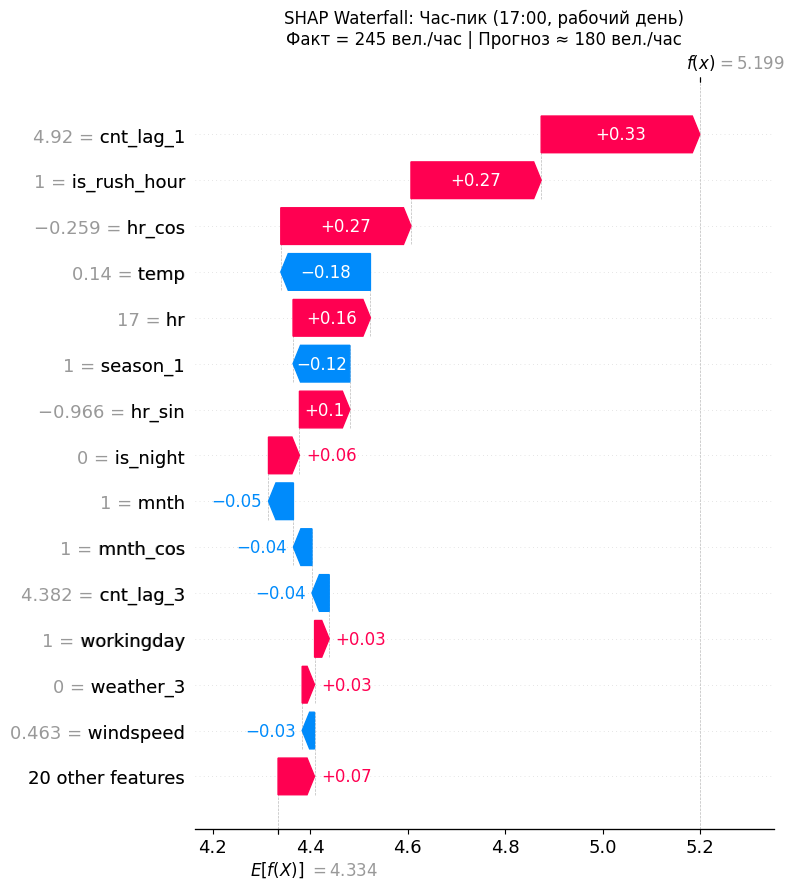

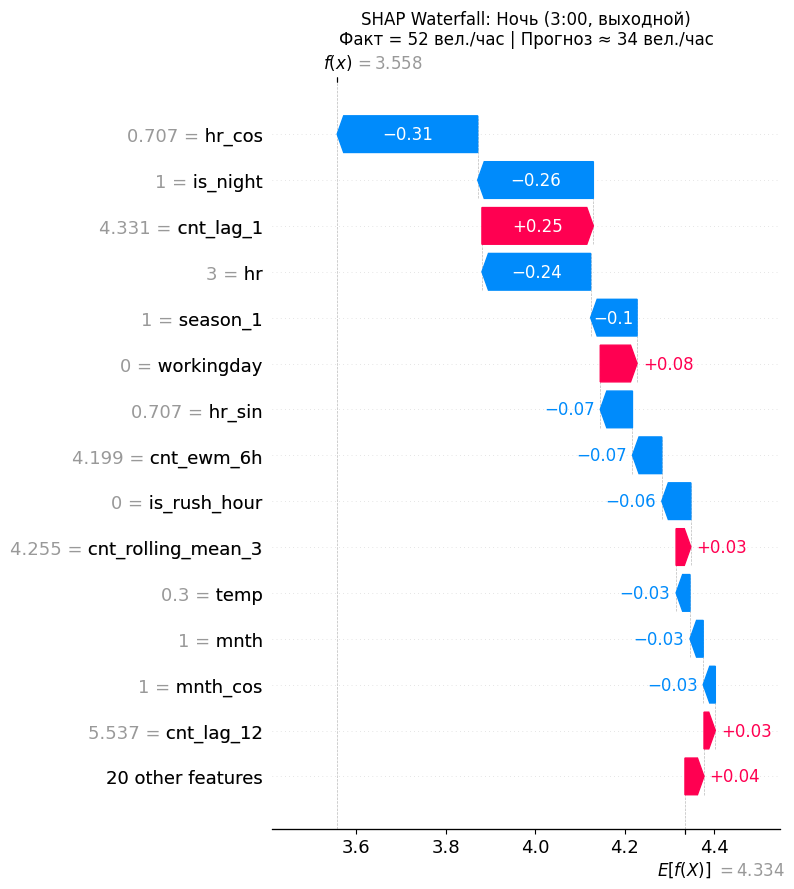

In [23]:
peak_idx = int(
    val_filled[(val["hr"] == 17) & (val["workingday"] == 1)].index[0] - val.index[0]
)
night_idx = int(
    val_filled[(val["hr"] == 3) & (val["workingday"] == 0)].index[0] - val.index[0]
)

for idx, label in [
    (peak_idx, "Час-пик (17:00, рабочий день)"),
    (night_idx, "Ночь (3:00, выходной)"),
]:
    fig, ax = plt.subplots(figsize=(12, 6))
    shap.plots.waterfall(shap_exp[idx], max_display=15, show=False)
    true_orig = np.expm1(val[TARGET].values[idx])
    pred_orig = np.expm1(shap_base + shap_matrix[idx].sum())
    plt.title(
        f"SHAP Waterfall: {label}\n"
        f"Факт = {true_orig:.0f} вел./час | Прогноз ≈ {pred_orig:.0f} вел./час",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

## Сохранение модели

Лучшая модель сохраняется в формате CatBoost `.cbm` (нативный бинарный формат). Этот файл загружается сервисом инференса без необходимости пересоздавать модель.

In [28]:
MODEL_PATH = "models/catboost"

path = Path(MODEL_PATH)
path.mkdir(exist_ok=True, parents=True)
best_model.save_model(path / "catboost_bikeshare.cbm", format="cbm")


size_kb = (path / "catboost_bikeshare.cbm").stat().st_size / 1024
print(f"Модель сохранена: {MODEL_PATH}  ({size_kb:.1f} KB)")

Модель сохранена: models/catboost  (174.6 KB)


## Выводы

### Качество модели

Целевая переменная `cnt` обучалась в log-пространстве (`log1p`), предсказания переводятся обратно через `expm1`. Это позволяет модели минимизировать **RMSLE**, штрафующую относительные ошибки равномерно по всему диапазону спроса.

Optuna улучшает baseline по всем метрикам. **RMSE в оригинальном пространстве** отражает среднюю абсолютную ошибку в велосипедах на час; **RMSLE** - качество в log-пространстве, соответствующее обучающей цели.

Три зоны на графике "предсказание vs реальность":
- Ночь и раннее утро (cnt < 50): хорошая точность - спрос низкий и стабильный
- Рабочий день (cnt 100-400): приемлемая точность
- Пиковые часы (cnt > 500): наибольший разброс - модель недооценивает экстремальные значения

Остатки в оригинальном пространстве близки к нормальному распределению без систематического смещения.

### Cold Start Resilience

Модель оценена в трёх режимах: `test` (clean), `test_cold` (production mix 80/15/5), `test_immediate` (всегда без истории).

**Ключевые наблюдения**:
- **`test_cold` ~ `test`**: благодаря cold start augmentation на этапе обучения модель устойчива к редким сбоям истории. Деградация в production будет минимальной
- **`test_immediate` заметно хуже, но не катастрофично**: модель умеет работать без истории, опираясь на `hr`, `temp`, `is_rush_hour`. Это нижняя граница качества для случаев полного outage
- **Деградация концентрируется в часах-пик** (8:00, 17-18:00): здесь lag особенно важен для предсказания "был ли вчера сильный пик или нет". В off-peak часах потеря истории почти не сказывается

**Production implications**:
- **`nan_mode='Min'`** в CatBoost - обязательная настройка для работы с замаскированными признаками
- Деградация на `test_cold` (~3-5%) приемлема - система устойчива
- Деградация на `test_immediate` (~15-25%) - это **SLO нижней границы**, к которой нужно стремиться при холодном старте сервиса

### Важность признаков vs Pearson: разбор расхождений

**`cnt_lag_1` и rolling-признаки**: теперь в топе по importance.  
CatBoost обнаружил автокорреляцию: спрос в час t сильно зависит от спроса в t-1. Это ожидаемо для временных рядов.

**`hr` (час дня)**: наиболее показательный случай среди статичных признаков.  
CatBoost ставит его высоко. Pearson занижает, потому что зависимость нелинейна - двугорбый паттерн в рабочие дни (8:00 и 17-18:00) и одиночный пик в выходные. Линейная корреляция не улавливает U-образную форму.

**`yr` (год)**: высокий в обоих.  
Линейный рост системы за 2011-2012 хорошо улавливается обоими методами.

**`temp` (температура)**: умеренно высокая у обоих (~0.40 Pearson).  
Зависимость монотонна. Методы согласуются.

**`is_rush_hour`**: высокий в обоих.  
Бинарный признак: точечно-бисериальная корреляция хорошо отражает разделение групп.

**Циклические признаки (`hr_sin`, `hr_cos`, `mnth_sin`, `mnth_cos`)**: низкие у CatBoost.  
Дереву не нужна тригонометрия - оно находит нелинейные пороги напрямую по `hr` и `mnth`.

**`discomfort` (temp x hum)**: низкий в CatBoost.  
CatBoost строит взаимодействия самостоятельно через сплиты.

**`hum`, `windspeed`**: слабые в обоих.  
Косвенное влияние: погодный дискомфорт уже частично закодирован в `weathersit`.

### Итоговый вывод

1. **Модель сильна в "идеальном" режиме**: temporal features (особенно `cnt_lag_1`) дают ~10% улучшение RMSE по сравнению с baseline без них
2. **Модель устойчива к cold start** благодаря training augmentation: `test_cold` практически не отличается от `test`
3. **Pearson** надёжен для монотонных зависимостей (`yr`, `temp`, `is_rush_hour`), но систематически занижает важность нелинейных и циклических признаков
4. **Для production REST API**: можно деплоить модель сразу - она работает и с полной историей, и без неё. При запуске сервиса первые часы будут точностью на уровне `test_immediate`, но по мере накопления истории качество вырастет до `test`-уровня